Dependencies installed
Libraries loaded
Using device: cuda
Loading tokenizer...


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Dataset size: 50
Running experiment...


  0%|          | 0/50 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  2%|▏         | 1/50 [00:02<01:59,  2.44s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  4%|▍         | 2/50 [00:04<01:53,  2.37s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end 

Experiment finished
CSV saved
Plot saved

FILES CREATED:
answer_invariance_results.csv
answer_invariance_histogram.png


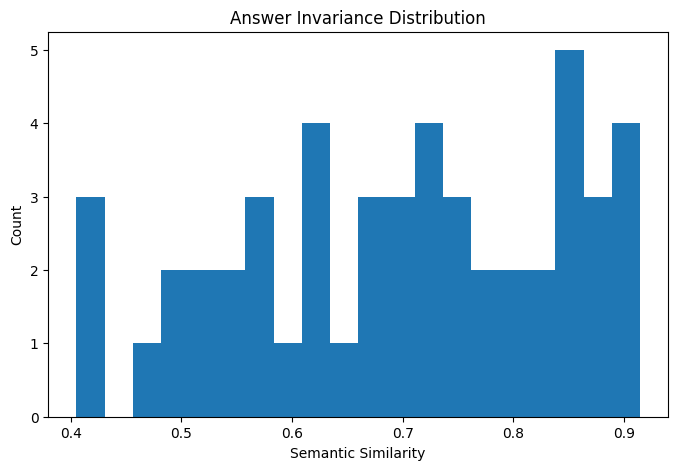

In [1]:
# =========================================================
# INSTALL DEPENDENCIES
# =========================================================
!pip install -q transformers datasets sentence-transformers pandas matplotlib tqdm torch

print("Dependencies installed")

# =========================================================
# IMPORTS
# =========================================================
import torch
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer, util

print("Libraries loaded")

# =========================================================
# DEVICE SETUP
# =========================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# =========================================================
# LOAD MODEL
# =========================================================
model_name = "mistralai/Mistral-7B-Instruct-v0.2"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Loading model (this may take ~30s)...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16
).to(device)

model.eval()

print("LLM ready")

# =========================================================
# LOAD EMBEDDING MODEL
# =========================================================
print("Loading embedding model...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model ready")

# =========================================================
# LOAD DATASET
# =========================================================
print("Loading dataset...")
dataset = load_dataset("squad", split="validation[:50]")

print("Dataset size:", len(dataset))

# =========================================================
# GENERATION FUNCTION
# =========================================================
def generate(prompt, max_tokens=40):

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        temperature=0.2,
        do_sample=False
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return text[len(prompt):].strip()

# =========================================================
# RUN EXPERIMENT
# =========================================================
print("Running experiment...")

records = []

for item in tqdm(dataset):

    question = item["question"]

    # generate paraphrases
    paraphrase_prompt = f"Rewrite this question in two different ways:\n\n{question}"
    paraphrases = generate(paraphrase_prompt, 60)

    p_list = paraphrases.split("\n")

    if len(p_list) < 2:
        continue

    p1 = p_list[0]
    p2 = p_list[1]

    questions = [question, p1, p2]

    answers = []

    for q in questions:
        ans = generate(f"Answer briefly:\n\n{q}")
        answers.append(ans)

    embeddings = embedder.encode(answers)

    sim1 = util.cos_sim(embeddings[0], embeddings[1]).item()
    sim2 = util.cos_sim(embeddings[0], embeddings[2]).item()

    invariance = (sim1 + sim2) / 2

    records.append({
        "question": question,
        "invariance": invariance
    })

print("Experiment finished")

# =========================================================
# SAVE RESULTS
# =========================================================
df = pd.DataFrame(records)

df.to_csv("answer_invariance_results.csv", index=False)

print("CSV saved")

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(8,5))

plt.hist(df["invariance"], bins=20)

plt.title("Answer Invariance Distribution")
plt.xlabel("Semantic Similarity")
plt.ylabel("Count")

plt.savefig("answer_invariance_histogram.png")

print("Plot saved")

print("\nFILES CREATED:")
print("answer_invariance_results.csv")
print("answer_invariance_histogram.png")


Starting Answer Flip Experiment


  0%|          | 0/50 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  2%|▏         | 1/50 [00:02<01:44,  2.13s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  4%|▍         | 2/50 [00:04<01:47,  2.23s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  6%|▌         | 3/50 [00:06<01:50,  2.36s/it]Setting 

Flip rate: 1.0
Files saved:
answer_flip_results.csv
answer_flip_plot.png


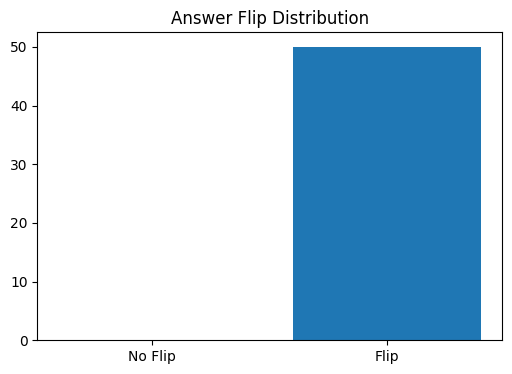

In [2]:
# =====================================================
# SECOND EXPERIMENT: ANSWER FLIP RATE
# =====================================================

print("Starting Answer Flip Experiment")

from datasets import load_dataset
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

dataset = load_dataset("squad", split="validation[:50]")

def generate(prompt, max_tokens=40):

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        temperature=0.2,
        do_sample=False
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return text[len(prompt):].strip()

records = []
flips = 0
total = 0

for item in tqdm(dataset):

    question = item["question"]

    # create paraphrases
    paraphrase_prompt = f"Rewrite this question in two different ways:\n\n{question}"
    paraphrases = generate(paraphrase_prompt, 60)

    p_list = paraphrases.split("\n")

    if len(p_list) < 2:
        continue

    p1 = p_list[0]
    p2 = p_list[1]

    # answers
    a0 = generate(f"Answer briefly:\n\n{question}")
    a1 = generate(f"Answer briefly:\n\n{p1}")
    a2 = generate(f"Answer briefly:\n\n{p2}")

    answers = [a0.lower(), a1.lower(), a2.lower()]

    flip = not (answers[0] == answers[1] == answers[2])

    if flip:
        flips += 1

    total += 1

    records.append({
        "original": a0,
        "paraphrase1": a1,
        "paraphrase2": a2,
        "flip": flip
    })

df_flip = pd.DataFrame(records)

flip_rate = flips / total

print("Flip rate:", flip_rate)

df_flip.to_csv("answer_flip_results.csv", index=False)

plt.figure(figsize=(6,4))
plt.bar(["No Flip","Flip"], [total-flips, flips])
plt.title("Answer Flip Distribution")
plt.savefig("answer_flip_plot.png")

print("Files saved:")
print("answer_flip_results.csv")
print("answer_flip_plot.png")


In [3]:
df["invariance"].mean()


np.float64(0.6968344015441835)